In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import cv2

In [3]:
crack_folder = "448/Cracks"
normal_folder = "448/NonCracks"

print("Crack directory available:", os.path.isdir(crack_folder))
print("Non-crack directory available:", os.path.isdir(normal_folder))

Crack directory available: True
Non-crack directory available: True


In [4]:
valid_formats = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def collect_images(folder):
    return [
        os.path.join(folder, filename)
        for filename in os.listdir(folder)
        if os.path.splitext(filename)[1].lower() in valid_formats
    ]

crack_paths = collect_images(crack_folder)
non_crack_paths = collect_images(normal_folder)

print(f"Crack images     : {len(crack_paths)}")
print(f"Non-crack images : {len(non_crack_paths)}")
print(f"Total images     : {len(crack_paths) + len(non_crack_paths)}")

Crack images     : 200
Non-crack images : 200
Total images     : 400


In [5]:
crack_sample = Image.open(crack_paths[0])
normal_sample = Image.open(non_crack_paths[0])

for title, picture in [("Crack", crack_sample), ("Non-crack", normal_sample)]:
    print(f"\n{title} image")
    print("Dimensions:", picture.size)
    print("Image mode:", picture.mode)

sample_pixels = np.asarray(crack_sample)

print("\nArray information")
print("Shape:", sample_pixels.shape)
print("Data type:", sample_pixels.dtype)
print("Pixel range:", sample_pixels.min(), "to", sample_pixels.max())


Crack image
Dimensions: (448, 448)
Image mode: RGB

Non-crack image
Dimensions: (448, 448)
Image mode: RGB

Array information
Shape: (448, 448, 3)
Data type: uint8
Pixel range: 0 to 255


In [6]:
records = []

for category, file_list, class_id in [
    ("Crack", crack_paths, 1),
    ("Non-crack", non_crack_paths, 0)
]:
    for path in file_list:
        pixel_data = np.asarray(Image.open(path))

        records.append({
            "filename": os.path.basename(path),
            "label": class_id,
            "height": pixel_data.shape[0],
            "width": pixel_data.shape[1],
            "channels": 1 if pixel_data.ndim == 2 else pixel_data.shape[-1],
            "dtype": pixel_data.dtype,
            "min_pixel": pixel_data.min(),
            "max_pixel": pixel_data.max()
        })

image_info = pd.DataFrame(records)

display(image_info.head())

print("Inspection table shape:", image_info.shape)

print("\nDistinct image dimensions:")
display(image_info[["height", "width", "channels"]].drop_duplicates())

print("\nNumber of images in each class:")
display(image_info["label"].value_counts())

,filename,label,height,width,channels,dtype,min_pixel,max_pixel
0,IMG_20180513_164959951_HDR resized_448.jpg,1,448,448,3,uint8,0,255
1,IMG_20180513_165129852_HDR resized_448.jpg,1,448,448,3,uint8,0,255
2,IMG_20180513_165150613_HDR resized_448.jpg,1,448,448,3,uint8,0,255
3,IMG_20180513_165345878_HDR resized_448.jpg,1,448,448,3,uint8,0,255
4,IMG_20180513_165349788_HDR resized_448.jpg,1,448,448,3,uint8,0,255


Inspection table shape: (400, 8)

Distinct image dimensions:


,height,width,channels
0,448,448,3



Number of images in each class:


label
1    200
0    200
Name: count, dtype: int64

In [7]:
TARGET_SIZE = (128, 128)

def prepare_image(path, size=TARGET_SIZE):
    image = Image.open(path)

    # Reduce the image to one intensity channel
    gray = image.convert("L")

    # Make every image the same spatial size
    gray = gray.resize(size)

    return np.asarray(gray)

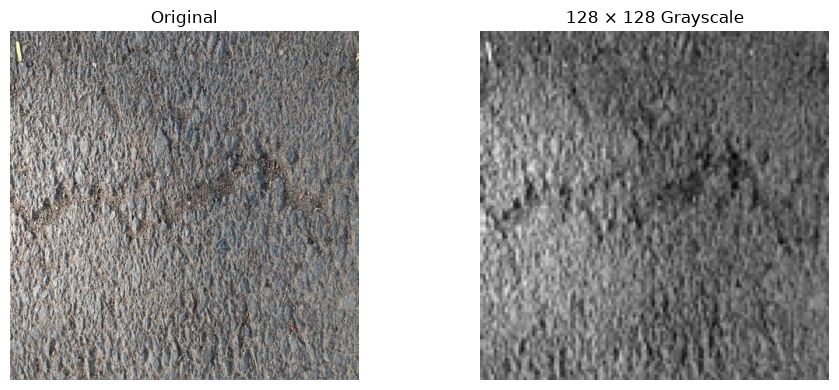

In [8]:
example = crack_paths[0]

before = Image.open(example)
after = prepare_image(example)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(before)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(after, cmap="gray")
axes[1].set_title("128 × 128 Grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
processed_images = []
image_labels = []
image_names = []

dataset_groups = [
    (crack_paths, 1),
    (non_crack_paths, 0)
]

for paths, class_label in dataset_groups:
    for path in paths:
        processed_images.append(prepare_image(path))
        image_labels.append(class_label)
        image_names.append(os.path.basename(path))

In [10]:
X_images = np.asarray(processed_images)
y_images = np.asarray(image_labels)

print("Image array shape:", X_images.shape)
print("Label array shape:", y_images.shape)

unique_labels, counts = np.unique(y_images, return_counts=True)

for label, count in zip(unique_labels, counts):
    class_name = "Crack" if label == 1 else "Non-crack"
    print(f"{class_name}: {count}")

Image array shape: (400, 128, 128)
Label array shape: (400,)
Non-crack: 200
Crack: 200


In [11]:
def get_intensity_features(image):
    """Calculate statistical features from a grayscale image."""
    
    values = image.astype(np.float64).ravel()

    return {
        "mean_brightness": values.mean(),
        "std_intensity": values.std(),
        "variance": values.var(),
        "min_intensity": values.min(),
        "max_intensity": values.max(),
        "median_intensity": np.median(values),
        "dark_ratio": np.mean(values < 50),
        "bright_ratio": np.mean(values > 200)
    }

In [12]:
feature_records = [
    get_intensity_features(img)
    for img in X_images
]

image_features_df = pd.DataFrame(feature_records)

display(image_features_df.head())

,mean_brightness,std_intensity,variance,min_intensity,max_intensity,median_intensity,dark_ratio,bright_ratio
0,122.085083,25.113693,630.697595,42.0,234.0,120.0,0.000305,0.002686
1,131.831848,19.940848,397.637435,30.0,219.0,133.0,0.001404,0.001038
2,121.172485,24.277407,589.392490,4.0,225.0,121.0,0.006775,0.002747
3,130.120239,19.731231,389.321480,41.0,255.0,131.0,0.000305,0.001526
4,131.076355,19.815623,392.658904,40.0,255.0,132.0,0.000610,0.002258


In [13]:
image_features_df.insert(0, "filename", image_names)
image_features_df["label"] = y_images

print("Feature dataset shape:", image_features_df.shape)

print("\nStatistical summary:")
display(
    image_features_df
    .drop(columns=["filename", "label"])
    .describe()
    .T
)

print("\nAverage feature values by class:")
class_summary = image_features_df.groupby("label").mean(numeric_only=True)
display(class_summary)

Feature dataset shape: (400, 10)

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
mean_brightness,400.0,150.873916,17.756734,110.349792,134.368576,152.751953,166.010727,189.697815
std_intensity,400.0,20.830510,6.925746,10.434267,15.024902,19.588995,24.974604,42.857227
variance,400.0,481.756175,332.545162,108.873934,225.747836,383.728835,623.730888,1836.741918
min_intensity,400.0,64.885000,36.748373,0.000000,36.000000,68.000000,98.250000,130.000000
max_intensity,400.0,241.057500,13.486248,191.000000,233.000000,245.000000,253.000000,255.000000
median_intensity,400.0,151.045000,17.771820,111.000000,135.750000,153.000000,166.000000,190.000000
dark_ratio,400.0,0.001942,0.005643,0.000000,0.000000,0.000000,0.000732,0.054749
bright_ratio,400.0,0.027080,0.038393,0.000000,0.002869,0.008850,0.039047,0.230774



Average feature values by class:


,mean_brightness,std_intensity,variance,min_intensity,max_intensity,median_intensity,dark_ratio,bright_ratio
label,,,,,,,,
0,157.503142,17.079395,311.435596,90.28,235.710,157.245,0.000015,0.014915
1,144.244691,24.581624,652.076753,39.49,246.405,144.845,0.003870,0.039246


In [14]:
def get_edge_features(image, lower=50, upper=150):
    """Detect edges and calculate edge-related measurements."""
    
    edge_map = cv2.Canny(image, lower, upper)

    number_of_edges = np.count_nonzero(edge_map)
    pixel_count = edge_map.size
    edge_ratio = number_of_edges / pixel_count

    return edge_map, number_of_edges, edge_ratio

In [15]:
edge_counts = []
edge_ratios = []

for img in X_images:
    _, count, ratio = get_edge_features(
        img,
        lower=50,
        upper=150
    )

    edge_counts.append(count)
    edge_ratios.append(ratio)

image_features_df["edge_count"] = edge_counts
image_features_df["edge_density"] = edge_ratios

print("Average edge measurements by class:")

edge_summary = (
    image_features_df
    .groupby("label")[["edge_count", "edge_density"]]
    .mean()
)

display(edge_summary)

Average edge measurements by class:


,edge_count,edge_density
label,,
0,4230.835,0.258230
1,5672.950,0.346249


In [16]:
output_file = "image_features.csv"

image_features_df.to_csv(output_file, index=False)

print(f"Feature data saved as: {output_file}")

Feature data saved as: image_features.csv


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import time

In [18]:
selected_features = [
    "mean_brightness",
    "std_intensity",
    "variance",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "dark_ratio",
    "bright_ratio",
    "edge_count",
    "edge_density"
]

X = image_features_df[selected_features]
y = image_features_df["label"]

print("Feature matrix:", X.shape)
print("Target vector :", y.shape)

Feature matrix: (400, 10)
Target vector : (400,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape)
print("Testing samples :", X_test_scaled.shape)

Training samples: (320, 10)
Testing samples : (80, 10)


In [20]:
model_collection = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [21]:
fitted_models = {}
fit_duration = {}

for model_name, classifier in model_collection.items():

    start = time.perf_counter()

    classifier.fit(X_train_scaled, y_train)

    elapsed = time.perf_counter() - start

    fitted_models[model_name] = classifier
    fit_duration[model_name] = elapsed

    print(f"{model_name}: {elapsed:.6f} seconds")

Logistic Regression: 0.047085 seconds
Decision Tree: 0.009426 seconds
Random Forest: 0.332845 seconds


In [22]:
model_predictions = {}
prediction_duration = {}

for model_name, classifier in fitted_models.items():

    start = time.perf_counter()

    predicted_labels = classifier.predict(X_test_scaled)

    elapsed = time.perf_counter() - start

    model_predictions[model_name] = predicted_labels
    prediction_duration[model_name] = elapsed

    print(f"{model_name}: {elapsed:.6f} seconds")

Logistic Regression: 0.000968 seconds
Decision Tree: 0.009567 seconds
Random Forest: 0.101974 seconds


In [23]:
evaluation_rows = []

for model_name, predicted_labels in model_predictions.items():

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predicted_labels),
        "Precision": precision_score(
            y_test, predicted_labels, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predicted_labels, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, predicted_labels, zero_division=0
        ),
        "Training Time (s)": fit_duration[model_name],
        "Prediction Time (s)": prediction_duration[model_name]
    })

results_df = pd.DataFrame(evaluation_rows)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0471,0.0010
1,Decision Tree,0.9375,0.9487,0.925,0.9367,0.0094,0.0096
2,Random Forest,0.9375,0.9268,0.950,0.9383,0.3328,0.1020


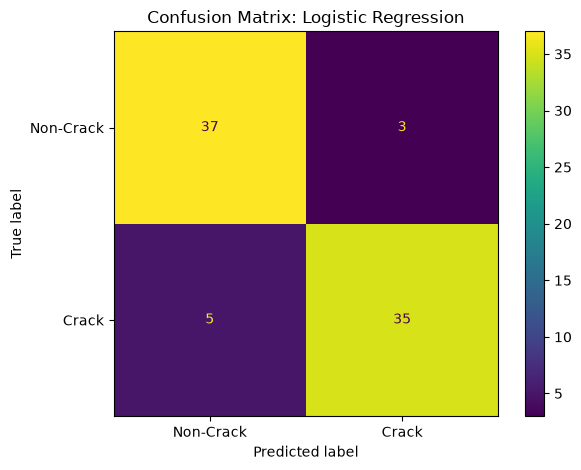

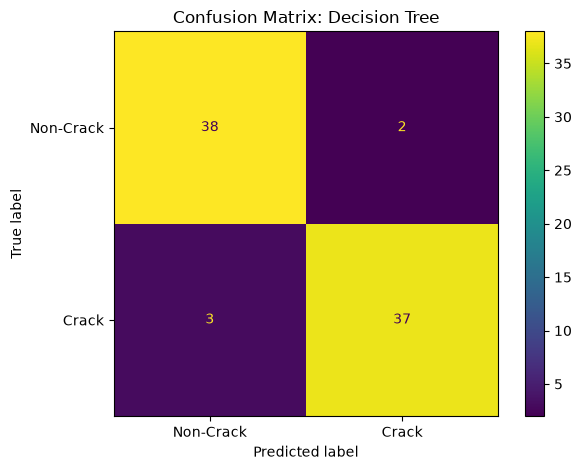

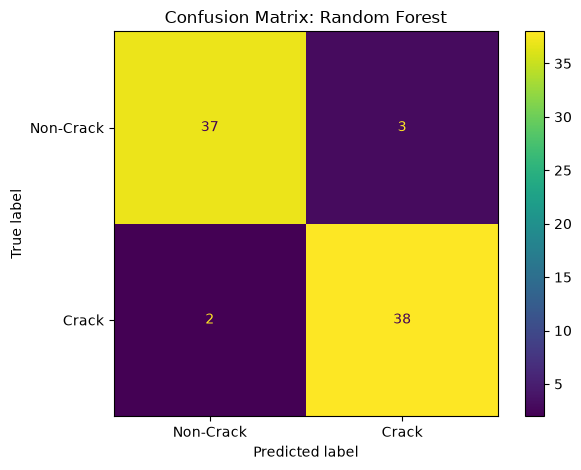

In [24]:
for model_name, predicted_labels in model_predictions.items():

    matrix = confusion_matrix(
        y_test,
        predicted_labels
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Non-Crack", "Crack"]
    )

    display_matrix.plot()

    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()

    saved_name = (
        model_name
        .lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        saved_name,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [25]:
def get_refined_edges(image, lower=30, upper=100):
    """Extract edges using a more sensitive Canny configuration."""

    edge_map = cv2.Canny(image, lower, upper)

    edge_total = np.count_nonzero(edge_map)
    total_pixels = edge_map.size

    edge_ratio = edge_total / total_pixels

    return edge_map, edge_total, edge_ratio


refined_counts = []
refined_ratios = []

for img in X_images:

    _, count, ratio = get_refined_edges(
        img,
        lower=30,
        upper=100
    )

    refined_counts.append(count)
    refined_ratios.append(ratio)

In [26]:
improved_image_features_df = image_features_df.copy()

improved_image_features_df["edge_count"] = refined_counts
improved_image_features_df["edge_density"] = refined_ratios

print("Original edge statistics:")
display(
    image_features_df[
        ["edge_count", "edge_density"]
    ].describe()
)

print("\nRefined edge statistics:")
display(
    improved_image_features_df[
        ["edge_count", "edge_density"]
    ].describe()
)

Original edge statistics:


,edge_count,edge_density
count,400.000000,400.000000
mean,4951.892500,0.302240
std,1382.106471,0.084357
min,1307.000000,0.079773
25%,3874.750000,0.236496
50%,5621.000000,0.343079
75%,6028.000000,0.367920
max,6400.000000,0.390625



Refined edge statistics:


,edge_count,edge_density
count,400.000000,400.000000
mean,5938.130000,0.362435
std,346.075771,0.021123
min,4379.000000,0.267273
25%,5717.000000,0.348938
50%,6051.000000,0.369324
75%,6206.500000,0.378815
max,6452.000000,0.393799


In [27]:
X_refined = improved_image_features_df[selected_features]
y_refined = improved_image_features_df["label"]

X_train_refined, X_test_refined, y_train_refined, y_test_refined = (
    train_test_split(
        X_refined,
        y_refined,
        test_size=0.20,
        random_state=42,
        stratify=y_refined
    )
)

print("Refined training data:", X_train_refined.shape)
print("Refined testing data :", X_test_refined.shape)

Refined training data: (320, 10)
Refined testing data : (80, 10)


In [28]:
refined_scaler = StandardScaler()

X_train_refined_scaled = refined_scaler.fit_transform(
    X_train_refined
)

X_test_refined_scaled = refined_scaler.transform(
    X_test_refined
)

print("Scaling completed.")

Scaling completed.


In [29]:
refined_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [30]:
refined_predictions = {}
refined_training_time = {}
refined_prediction_time = {}

for model_name, classifier in refined_models.items():

    start = time.perf_counter()

    classifier.fit(
        X_train_refined_scaled,
        y_train_refined
    )

    refined_training_time[model_name] = (
        time.perf_counter() - start
    )

    start = time.perf_counter()

    predicted = classifier.predict(
        X_test_refined_scaled
    )

    refined_prediction_time[model_name] = (
        time.perf_counter() - start
    )

    refined_predictions[model_name] = predicted

In [31]:
refined_rows = []

for model_name, predicted in refined_predictions.items():

    refined_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_refined,
            predicted
        ),
        "Precision": precision_score(
            y_test_refined,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_refined,
            predicted,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test_refined,
            predicted,
            zero_division=0
        ),
        "Training Time (s)": refined_training_time[model_name],
        "Prediction Time (s)": refined_prediction_time[model_name]
    })

improved_results_df = pd.DataFrame(refined_rows)

display(improved_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0208,0.0005
1,Decision Tree,0.9375,0.9487,0.925,0.9367,0.0034,0.0007
2,Random Forest,0.9250,0.9048,0.950,0.9268,0.2815,0.0396


In [32]:
baseline = results_df.copy()
baseline["Representation"] = "Original Canny (50/150)"

refined = improved_results_df.copy()
refined["Representation"] = "Improved Canny (30/100)"

comparison_df = pd.concat(
    [baseline, refined],
    ignore_index=True
)

comparison_df = comparison_df[
    [
        "Representation",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time (s)",
        "Prediction Time (s)"
    ]
]

display(comparison_df.round(4))

,Representation,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original Canny (50/150),Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0471,0.0010
1,Original Canny (50/150),Decision Tree,0.9375,0.9487,0.925,0.9367,0.0094,0.0096
2,Original Canny (50/150),Random Forest,0.9375,0.9268,0.950,0.9383,0.3328,0.1020
3,Improved Canny (30/100),Logistic Regression,0.9000,0.9211,0.875,0.8974,0.0208,0.0005
4,Improved Canny (30/100),Decision Tree,0.9375,0.9487,0.925,0.9367,0.0034,0.0007
5,Improved Canny (30/100),Random Forest,0.9250,0.9048,0.950,0.9268,0.2815,0.0396


## PART B

In [33]:
email_data = pd.read_csv("emails.csv")

print("Dataset shape:", email_data.shape)

print("\nFirst five records:")
display(email_data.head())

print("\nAvailable columns:")
print(email_data.columns.tolist())

print("\nDataset information:")
email_data.info()

Dataset shape: (5172, 3002)

First five records:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0



Available columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flo

In [34]:
print("Missing values:")
display(email_data.isnull().sum())

print("\nTarget distribution:")
display(email_data["Prediction"].value_counts())

print("\nTarget percentages:")
display(
    email_data["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
)

print("\nData types:")
display(email_data.dtypes.value_counts())

first_column = email_data.columns[0]

print("\nFirst column:", first_column)
print(
    "Unique values in first column:",
    email_data[first_column].nunique()
)

Missing values:


Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64


Target distribution:


Prediction
0    3672
1    1500
Name: count, dtype: int64


Target percentages:


Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


Data types:


int64    3001
str         1
Name: count, dtype: int64


First column: Email No.
Unique values in first column: 5172


In [35]:
identifier = email_data.columns[0]

email_model_data = email_data.drop(
    columns=identifier
)

X_email = email_model_data.drop(
    columns="Prediction"
)

y_email = email_model_data["Prediction"]

print("Input feature shape :", X_email.shape)
print("Target shape        :", y_email.shape)

print("\nClass counts:")
print(y_email.value_counts())

Input feature shape : (5172, 3000)
Target shape        : (5172,)

Class counts:
Prediction
0    3672
1    1500
Name: count, dtype: int64


In [36]:
X_train_email, X_test_email, y_train_email, y_test_email = (
    train_test_split(
        X_email,
        y_email,
        test_size=0.20,
        random_state=42,
        stratify=y_email
    )
)

print("Training set:", X_train_email.shape)
print("Testing set :", X_test_email.shape)

Training set: (4137, 3000)
Testing set : (1035, 3000)


In [37]:
email_model_collection = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [38]:
email_fitted_models = {}
email_fit_times = {}

for model_name, classifier in email_model_collection.items():

    start = time.perf_counter()

    classifier.fit(
        X_train_email,
        y_train_email
    )

    elapsed = time.perf_counter() - start

    email_fitted_models[model_name] = classifier
    email_fit_times[model_name] = elapsed

    print(
        f"{model_name} training time: "
        f"{elapsed:.4f} seconds"
    )

Logistic Regression training time: 9.2975 seconds
Decision Tree training time: 1.0473 seconds
Random Forest training time: 0.7785 seconds


In [39]:
email_predictions = {}
email_predict_times = {}

for model_name, classifier in email_fitted_models.items():

    start = time.perf_counter()

    predicted = classifier.predict(X_test_email)

    elapsed = time.perf_counter() - start

    email_predictions[model_name] = predicted
    email_predict_times[model_name] = elapsed

    print(
        f"{model_name} prediction time: "
        f"{elapsed:.4f} seconds"
    )

Logistic Regression prediction time: 0.1554 seconds
Decision Tree prediction time: 0.0626 seconds
Random Forest prediction time: 0.1221 seconds


In [48]:
email_score_rows = []

for model_name, predicted in email_predictions.items():

    email_score_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_email,
            predicted
        ),
        "Precision": precision_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "Training Time (s)": email_fit_times[model_name],
        "Prediction Time (s)": email_predict_times[model_name]
    })

email_results_df = pd.DataFrame(email_score_rows)

display(email_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9826,0.9578,0.9833,0.9704,9.2975,0.1554
1,Decision Tree,0.9188,0.8699,0.8467,0.8581,1.0473,0.0626
2,Random Forest,0.9643,0.9340,0.9433,0.9386,0.7785,0.1221


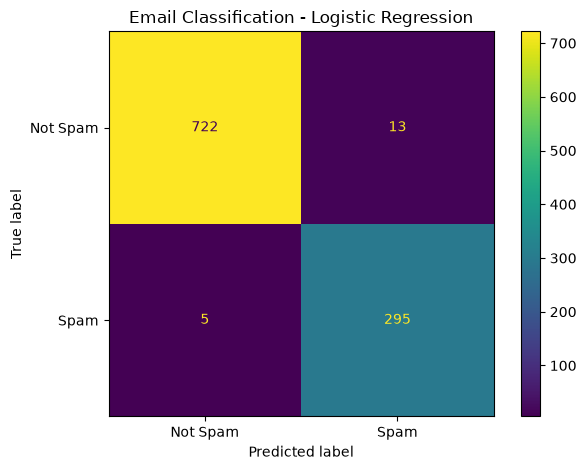

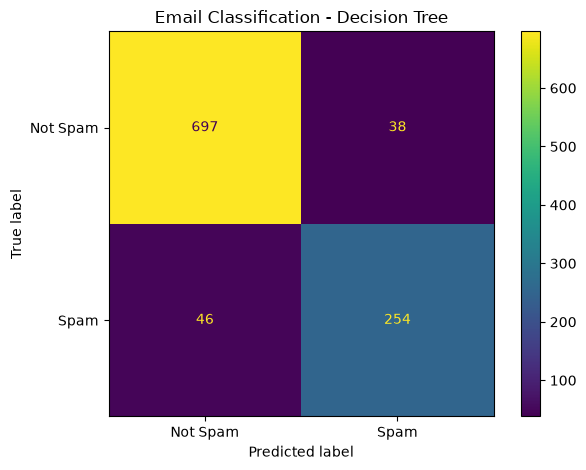

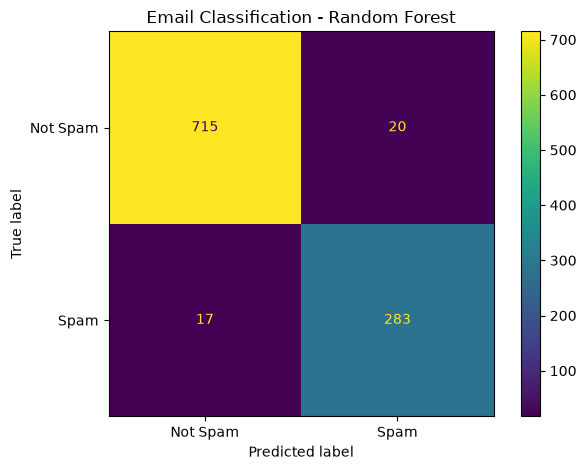

In [49]:
for model_name, predicted in email_predictions.items():

    matrix = confusion_matrix(
        y_test_email,
        predicted
    )

    chart = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Not Spam", "Spam"]
    )

    chart.plot()

    plt.title(f"Email Classification - {model_name}")
    plt.tight_layout()

    file_name = (
        "email_confusion_matrix_"
        + model_name.lower().replace(" ", "_")
        + ".png"
    )

    plt.savefig(
        file_name,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# PART-C

### Improvement for PART-A

In [50]:
edge_density_check = pd.DataFrame({
    "Original": image_features_df["edge_density"],
    "Improved": improved_image_features_df["edge_density"]
})

edge_density_check["Difference"] = (
    edge_density_check["Improved"]
    - edge_density_check["Original"]
)

display(edge_density_check.head())

original_average = image_features_df["edge_density"].mean()
improved_average = improved_image_features_df["edge_density"].mean()

print(f"Average original edge density: {original_average:.6f}")
print(f"Average improved edge density: {improved_average:.6f}")
print(f"Average change: {improved_average - original_average:.6f}")

,Original,Improved,Difference
0,0.350525,0.367065,0.016541
1,0.326294,0.371887,0.045593
2,0.300415,0.353027,0.052612
3,0.360291,0.378784,0.018494
4,0.333557,0.363037,0.029480


Average original edge density: 0.302240
Average improved edge density: 0.362435
Average change: 0.060195


In [51]:
original_f1_scores = (
    results_df
    .set_index("Model")["F1-Score"]
)

improved_f1_scores = (
    improved_results_df
    .set_index("Model")["F1-Score"]
)

f1_comparison = pd.DataFrame({
    "Original F1": original_f1_scores,
    "Improved F1": improved_f1_scores
})

f1_comparison["Difference"] = (
    f1_comparison["Improved F1"]
    - f1_comparison["Original F1"]
)

display(f1_comparison.round(4))

,Original F1,Improved F1,Difference
Model,,,
Logistic Regression,0.8974,0.8974,0.0000
Decision Tree,0.9367,0.9367,0.0000
Random Forest,0.9383,0.9268,-0.0114


### Improvement for PART-B

In [52]:
from sklearn.feature_selection import SelectKBest, chi2

top_features = SelectKBest(
    score_func=chi2,
    k=500
)

X_train_reduced = top_features.fit_transform(
    X_train_email,
    y_train_email
)

X_test_reduced = top_features.transform(
    X_test_email
)

print("Original training shape :", X_train_email.shape)
print("Reduced training shape  :", X_train_reduced.shape)

print("\nOriginal testing shape  :", X_test_email.shape)
print("Reduced testing shape   :", X_test_reduced.shape)

Original training shape : (4137, 3000)
Reduced training shape  : (4137, 500)

Original testing shape  : (1035, 3000)
Reduced testing shape   : (1035, 500)


In [53]:
reduced_email_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [54]:
reduced_email_fitted = {}
reduced_train_times = {}

print("Training times:")

for model_name, classifier in reduced_email_models.items():

    start = time.perf_counter()

    classifier.fit(
        X_train_reduced,
        y_train_email
    )

    elapsed = time.perf_counter() - start

    reduced_email_fitted[model_name] = classifier
    reduced_train_times[model_name] = elapsed

    print(
        f"{model_name}: {elapsed:.4f} seconds"
    )


reduced_email_predictions = {}
reduced_predict_times = {}

print("\nPrediction times:")

for model_name, classifier in reduced_email_fitted.items():

    start = time.perf_counter()

    predicted = classifier.predict(
        X_test_reduced
    )

    elapsed = time.perf_counter() - start

    reduced_email_predictions[model_name] = predicted
    reduced_predict_times[model_name] = elapsed

    print(
        f"{model_name}: {elapsed:.4f} seconds"
    )

Training times:
Logistic Regression: 4.0798 seconds
Decision Tree: 0.2892 seconds
Random Forest: 0.3667 seconds

Prediction times:
Logistic Regression: 0.0036 seconds
Decision Tree: 0.0026 seconds
Random Forest: 0.0571 seconds


In [56]:
reduced_email_scores = []

for model_name, predicted in reduced_email_predictions.items():

    reduced_email_scores.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_email,
            predicted
        ),
        "Precision": precision_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test_email,
            predicted,
            zero_division=0
        ),
        "Training Time (s)": reduced_train_times[model_name],
        "Prediction Time (s)": reduced_predict_times[model_name]
    })

improved_email_results_df = pd.DataFrame(
    reduced_email_scores
)

display(improved_email_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Logistic Regression,0.9652,0.9342,0.9467,0.9404,4.0798,0.0036
1,Decision Tree,0.9314,0.8855,0.8767,0.8811,0.2892,0.0026
2,Random Forest,0.9662,0.9316,0.9533,0.9423,0.3667,0.0571


In [57]:
columns_to_compare = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Training Time (s)",
    "Prediction Time (s)"
]

email_original = email_results_df[
    columns_to_compare
].copy()

email_original.insert(
    0,
    "Representation",
    "Original (3000 features)"
)


email_reduced = improved_email_results_df[
    columns_to_compare
].copy()

email_reduced.insert(
    0,
    "Representation",
    "Improved (500 features)"
)


email_comparison = pd.concat(
    [
        email_original,
        email_reduced
    ],
    ignore_index=True
)

display(
    email_comparison.round(4)
)

,Representation,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original (3000 features),Logistic Regression,0.9826,0.9578,0.9833,0.9704,9.2975,0.1554
1,Original (3000 features),Decision Tree,0.9188,0.8699,0.8467,0.8581,1.0473,0.0626
2,Original (3000 features),Random Forest,0.9643,0.9340,0.9433,0.9386,0.7785,0.1221
3,Improved (500 features),Logistic Regression,0.9652,0.9342,0.9467,0.9404,4.0798,0.0036
4,Improved (500 features),Decision Tree,0.9314,0.8855,0.8767,0.8811,0.2892,0.0026
5,Improved (500 features),Random Forest,0.9662,0.9316,0.9533,0.9423,0.3667,0.0571
